# 📊 A/B Test: Impact of Discount Messaging on Subscription Conversion
© Ihor Shvets
## ❗ Problem

Many users are hesitant to subscribe to premium app features at full price. It's unclear whether a promotional message (e.g., “50% discount”) can significantly influence user decisions and improve subscription rates.

## 🎯 Goal

To evaluate whether adding a “50% discount” message to the subscription offer increases the conversion rate compared to a standard offer without the discount label.

## 🛠️ Tools & Methodology

- **Python**  
- **Jupyter Notebook**  
- **Pandas** – for data manipulation  
- **Matplotlib & Seaborn** – for plotting (if needed)  
- **Statsmodels** – to perform a two-proportion Z-test  
- **Datetime** – for date parsing and duration calculations  

## **A/B Test Objective**:
   - **Group A**: Users were offered a subscription to access premium features of the app for $4.99.
   - **Group B**: Users were offered the same subscription, but with an added message that it was a special 50% discount offer.

1. **Test Duration and Time Period**
   - **Start Date**: 2023-07-03 01:42:34
   - **End Date**: 2023-07-25 01:41:19
   - **Test Duration**: 21 days

2. **Conversion Rates**
   - **Group A Conversion Rate**: 6.10%
   - **Group B Conversion Rate**: 8.90%

3. **Statistical Testing**
   - **Z-statistic**: -7.5197
   - **P-value**: 0.0000
   - **Decision**: The null hypothesis (which states there is no difference in conversion rates between Group A and Group B) has been rejected.


4. **Conclusion**
   - The change applied to Group B resulted in a higher conversion rate than Group A.
   - And this difference is unlikely to have occurred by chance.

**Recommendation**

Since the 50% discount offer in Group B resulted in a significantly higher conversion rate, it may be worth considering offering this type of discount to more users in the future to increase subscriptions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

data = pd.read_csv('ab_test_data.csv')
print(data.head())

                                user_id                   timestamp  \
0  7f6833e6-1141-4f20-b4b2-f1e31019b1fd  2023-07-04 04:40:55.848109   
1  e6a6e960-d3f3-4074-a516-ba1e609b211e  2023-07-06 00:26:45.486187   
2  4d3fbfa5-6847-410a-bac2-477f01d5f400  2023-07-10 20:24:33.639464   
3  361457d9-a044-48f7-981c-d67dc3861679  2023-07-20 07:04:49.957013   
4  285cd63d-7d03-427f-a062-1fa2dd2e77d6  2023-07-19 23:27:50.116680   

  test_group  conversion  
0          a           0  
1          b           0  
2          b           0  
3          b           0  
4          b           0  


In [2]:
# Calculate key metrics
group_metrics = data.groupby('test_group').agg(
    unique_users=('user_id', 'nunique'),  
    conversions=('conversion', 'sum')  
).reset_index()

# Conversion rate
group_metrics['conversion_rate'] = group_metrics['conversions'] / group_metrics['unique_users'] * 100

# Calculate test duration
data['timestamp'] = pd.to_datetime(data['timestamp']) 
start_date = data['timestamp'].min()  # Start date of the test
end_date = data['timestamp'].max()    # End date of the test
test_duration = (end_date - start_date).days  # Test duration in days

print(f"Test Start Date: {start_date}")
print(f"Test End Date: {end_date}")
print(f"Test Duration (days): {test_duration}\n")

print("Group Metrics:")
print(group_metrics)


Test Start Date: 2023-07-03 01:42:34.033708
Test End Date: 2023-07-25 01:41:19.152664
Test Duration (days): 21

Group Metrics:
  test_group  unique_users  conversions  conversion_rate
0          a         10013          611         6.102067
1          b          9985          889         8.903355


In [3]:
from statsmodels.stats.proportion import proportions_ztest

# Conversion and user counts
conversions = group_metrics['conversions'].values
users = group_metrics['unique_users'].values

# Perform z-test
z_stat, p_value = proportions_ztest(count=conversions, nobs=users)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference between the groups.")
else:
    print("Fail to reject the null hypothesis: No significant difference detected between the groups.")


Z-statistic: -7.5197
P-value: 0.0000
Reject the null hypothesis: There is a significant difference between the groups.


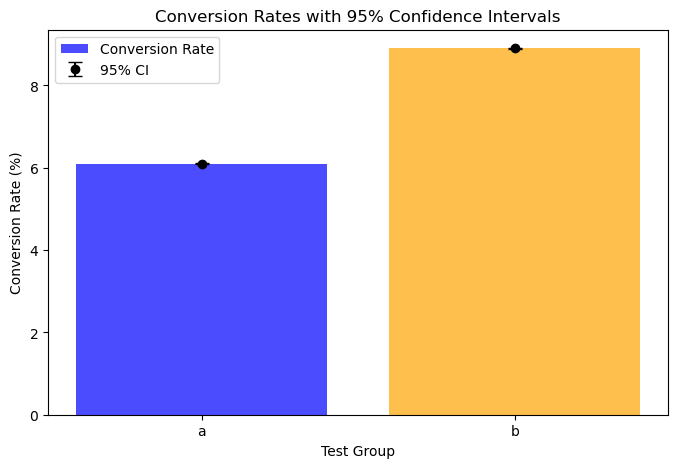

In [14]:

# Calculate confidence intervals
z = 1.96  # 95% confidence
group_metrics['ci_lower'] = group_metrics['conversion_rate'] - z * np.sqrt(
    (group_metrics['conversion_rate'] / 100 * (1 - group_metrics['conversion_rate'] / 100)) / group_metrics['unique_users']
)
group_metrics['ci_upper'] = group_metrics['conversion_rate'] + z * np.sqrt(
    (group_metrics['conversion_rate'] / 100 * (1 - group_metrics['conversion_rate'] / 100)) / group_metrics['unique_users']
)

# Plot conversion rates
plt.figure(figsize=(8, 5))
plt.bar(group_metrics['test_group'], group_metrics['conversion_rate'], color=['blue', 'orange'], alpha=0.7, label='Conversion Rate')
plt.errorbar(group_metrics['test_group'], group_metrics['conversion_rate'],
             yerr=[group_metrics['conversion_rate'] - group_metrics['ci_lower'], 
                   group_metrics['ci_upper'] - group_metrics['conversion_rate']],
             fmt='o', color='black', capsize=5, label='95% CI')

plt.title("Conversion Rates with 95% Confidence Intervals")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
plt.legend()
plt.show()

In [16]:
conversion_rate_A = group_metrics.loc[group_metrics['test_group'] == 'a', 'conversion_rate'].values
conversion_rate_B = group_metrics.loc[group_metrics['test_group'] == 'b', 'conversion_rate'].values

conversion_rate_A = conversion_rate_A[0] if conversion_rate_A.size > 0 else None
conversion_rate_B = conversion_rate_B[0] if conversion_rate_B.size > 0 else None

# Format conclusions with proper handling of None values for conversion rates
conclusions = f"""
**A/B Test Results:**
1. The test ran from {start_date} to {end_date}, lasting {test_duration} days.
2. Conversion rate for Group A: {'N/A' if conversion_rate_A is None else f'{conversion_rate_A:.2f}'}%
3. Conversion rate for Group B: {'N/A' if conversion_rate_B is None else f'{conversion_rate_B:.2f}'}%
4. Statistical testing:
    - Z-statistic: {z_stat:.4f}
    - P-value: {p_value:.4f}
    - {'Reject' if p_value < alpha else 'Fail to reject'} the null hypothesis
5. Based on the analysis, we {'reject' if p_value < alpha else 'fail to reject'} the null hypothesis and conclude that {'there is a significant difference' if p_value < alpha else 'there is no significant difference'} in conversion rates.
"""

print(conclusions)



**A/B Test Results:**
1. The test ran from 2023-07-03 01:42:34.033708 to 2023-07-25 01:41:19.152664, lasting 21 days.
2. Conversion rate for Group A: 6.10%
3. Conversion rate for Group B: 8.90%
4. Statistical testing:
    - Z-statistic: -7.5197
    - P-value: 0.0000
    - Reject the null hypothesis
5. Based on the analysis, we reject the null hypothesis and conclude that there is a significant difference in conversion rates.



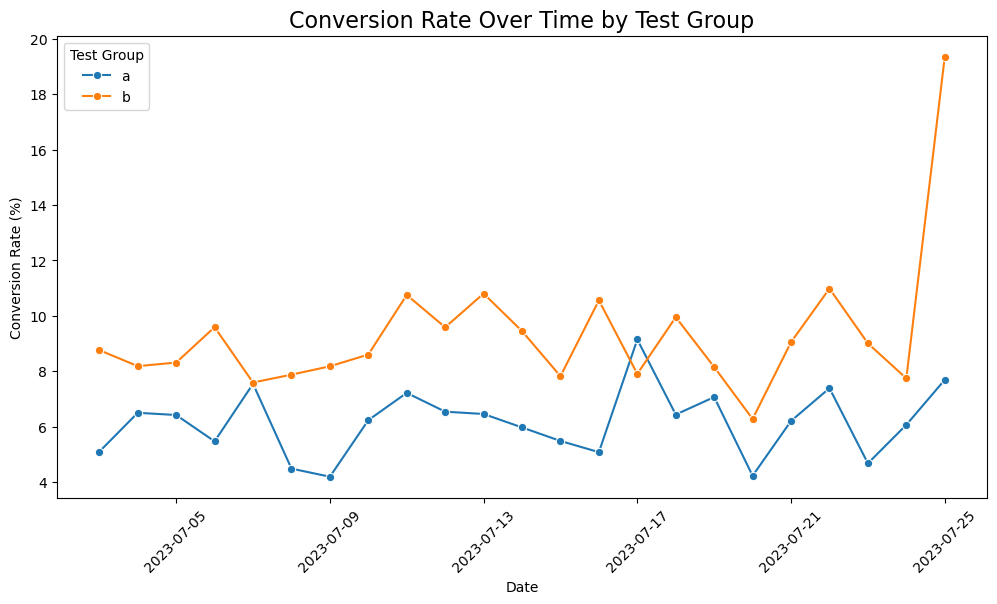

In [6]:
data['date'] = data['timestamp'].dt.date

# Calculate daily conversion rates
daily_metrics = data.groupby(['date', 'test_group']).agg(
    conversions=('conversion', 'sum'),
    unique_users=('user_id', 'nunique')
).reset_index()

# Calculate daily conversion rate
daily_metrics['conversion_rate'] = daily_metrics['conversions'] / daily_metrics['unique_users'] * 100

# Plot daily conversion rates over time for each group
plt.figure(figsize=(12, 6))

sns.lineplot(data=daily_metrics, x='date', y='conversion_rate', hue='test_group', marker='o')

plt.title('Conversion Rate Over Time by Test Group', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Test Group')
plt.show()
